# CSC3173: Artificial Intelligence (2024/25)
## S/21/513
### Programming Assignment 01
### Customer Churn Prediction: XGBoost vs Multilayer Perceptron (MLP)

**Dataset:** IBM Telco Customer Churn  
**Source:** Kaggle: [`yeanzc/telco-customer-churn-ibm-dataset`](https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset?select=Telco_customer_churn.xlsx)

This notebook builds a complete binary-classification pipeline, performs hyperparameter optimization for XGBoost and MLP, and compares Accuracy, Precision, Recall, and F1-score.


## 0. Imports and Reproducibility

Required packages: `pandas`, `openpyxl`, `scikit-learn`, `xgboost`, `tensorflow`, `matplotlib`.

For a `uv` project, they can be added with:

`uv add pandas openpyxl scikit-learn xgboost tensorflow matplotlib`


In [1]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from xgboost import XGBClassifier

import tensorflow as tf
import keras
from keras import layers
from keras.optimizers import Adam

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 1. Dataset Loading and Initial Inspection


In [2]:
candidate_paths = [
    Path("telco_customer_churn.xlsx"),
    Path("data/telco_customer_churn.xlsx"),
    Path("../data/telco_customer_churn.xlsx"),
]

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "telco_customer_churn.xlsx was not found. Place it beside the notebook "
        "or inside a data/ directory."
    )

df = pd.read_excel(DATA_PATH)
print("Dataset path:", DATA_PATH.resolve())
print("Dataset shape:", df.shape)
df.head()

Dataset path: C:\Users\sivot\Documents\CSC3173\assignment_01\data\telco_customer_churn.xlsx
Dataset shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Columns:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']

Missing values:
CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup  

In [5]:
target_counts = df["Churn Value"].value_counts().sort_index()
target_percent = df["Churn Value"].value_counts(normalize=True).sort_index() * 100

class_distribution = pd.DataFrame(
    {"Count": target_counts, "Percentage": target_percent.round(2)}
)
class_distribution.index = ["No Churn (0)", "Churn (1)"]
class_distribution

,Count,Percentage
No Churn (0),5174,73.46
Churn (1),1869,26.54


## 2. Data Cleaning and Feature Selection

Columns that directly reveal the target or contain post-churn information are removed to avoid target leakage. Identifier, constant, and unnecessary location-specific fields are also removed. `Churn Value` is retained as the binary target.


In [6]:
columns_to_drop = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",
    "Churn Score",
    "CLTV",
    "Churn Reason",
]

df = df.drop(columns=columns_to_drop).copy()

# Total Charges contains blank strings in this dataset, so convert it explicitly.
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
missing_total_charges = df["Total Charges"].isna().sum()
print("Missing Total Charges after numeric conversion:", missing_total_charges)

# Median imputation is fitted from the available dataset values for these few blank entries.
df["Total Charges"] = df["Total Charges"].fillna(df["Total Charges"].median())

print("Cleaned dataset shape:", df.shape)
df.head()

Missing Total Charges after numeric conversion: 11
Cleaned dataset shape: (7043, 20)


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


In [7]:
print("Remaining missing values:", int(df.isnull().sum().sum()))
print("Total Charges dtype:", df["Total Charges"].dtype)

Remaining missing values: 0
Total Charges dtype: float64


## 3. Train/Test Split and Preprocessing

Categorical variables are one-hot encoded. Numerical variables are standardized, which is especially useful for the MLP. The final test set is kept separate from hyperparameter selection.


In [8]:
X = df.drop(columns=["Churn Value"])
y = df["Churn Value"].astype(int)

categorical_columns = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()
numerical_columns = X.select_dtypes(include=["number"]).columns.tolist()

print("Features:", X.shape[1])
print("Categorical columns:", categorical_columns)
print("Numerical columns:", numerical_columns)

Features: 19
Categorical columns: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']
Numerical columns: ['Tenure Months', 'Monthly Charges', 'Total Charges']


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)
print("Training churn rate:", round(y_train.mean(), 4))
print("Testing churn rate :", round(y_test.mean(), 4))

Training set: (5634, 19)
Testing set : (1409, 19)
Training churn rate: 0.2654
Testing churn rate : 0.2654


In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        ("num", StandardScaler(), numerical_columns),
    ]
)

# These processed arrays are used by the baseline models and final MLP.
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape :", X_test_processed.shape)

Processed training shape:

 (5634, 46)
Processed testing shape : (1409, 46)


## 4. XGBoost Classifier


### 4.1 Baseline XGBoost


In [11]:
xgb_model = XGBClassifier(
    random_state=SEED,
    eval_metric="logloss",
)

xgb_model.fit(X_train_processed, y_train)
y_pred_xgb = xgb_model.predict(X_test_processed)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb, zero_division=0)
xgb_recall = recall_score(y_test, y_pred_xgb, zero_division=0)
xgb_f1 = f1_score(y_test, y_pred_xgb, zero_division=0)

print("XGBoost Baseline Performance")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-score : {xgb_f1:.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

XGBoost Baseline Performance
Accuracy : 0.7892
Precision: 0.6207
Recall   : 0.5294
F1-score : 0.5714

Classification report:

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



### 4.2 XGBoost Hyperparameter Optimization

`RandomizedSearchCV` performs 5-fold cross-validation on the training set only. F1-score is optimized because the churn classes are imbalanced. Preprocessing is included inside the pipeline so each cross-validation fold fits its own preprocessing transformations.


In [12]:
xgb_pipeline = Pipeline(
    [
        ("preprocess", clone(preprocessor)),
        ("xgb", XGBClassifier(random_state=SEED, eval_metric="logloss")),
    ]
)

xgb_param_dist = {
    "xgb__n_estimators": [100, 200, 300, 500],
    "xgb__max_depth": [3, 4, 5, 6, 8],
    "xgb__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "xgb__subsample": [0.7, 0.8, 0.9, 1.0],
    "xgb__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "xgb__min_child_weight": [1, 3, 5],
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=30,
    scoring="f1",
    cv=5,
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost parameters:")
for key, value in xgb_search.best_params_.items():
    print(f"  {key.replace('xgb__', '')}: {value}")
print(f"Best cross-validation F1-score: {xgb_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGBoost parameters:
  subsample: 0.9
  n_estimators: 200
  min_child_weight: 5
  max_depth: 3
  learning_rate: 0.05
  colsample_bytree: 0.8
Best cross-validation F1-score: 0.6142


In [13]:
best_xgb = xgb_search.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test)

xgb_tuned_accuracy = accuracy_score(y_test, y_pred_xgb_tuned)
xgb_tuned_precision = precision_score(y_test, y_pred_xgb_tuned, zero_division=0)
xgb_tuned_recall = recall_score(y_test, y_pred_xgb_tuned, zero_division=0)
xgb_tuned_f1 = f1_score(y_test, y_pred_xgb_tuned, zero_division=0)

print("Optimized XGBoost Performance")
print(f"Accuracy : {xgb_tuned_accuracy:.4f}")
print(f"Precision: {xgb_tuned_precision:.4f}")
print(f"Recall   : {xgb_tuned_recall:.4f}")
print(f"F1-score : {xgb_tuned_f1:.4f}")

Optimized XGBoost Performance
Accuracy : 0.8070
Precision: 0.6656
Recall   : 0.5481
F1-score : 0.6012


## 5. Multilayer Perceptron (MLP)


In [14]:
def to_dense(matrix):
    return matrix.toarray() if hasattr(matrix, "toarray") else np.asarray(matrix)


X_train_mlp = to_dense(X_train_processed).astype("float32")
X_test_mlp = to_dense(X_test_processed).astype("float32")
y_train_mlp = y_train.to_numpy(dtype="float32")
y_test_mlp = y_test.to_numpy(dtype="int32")

print("MLP training shape:", X_train_mlp.shape)
print("MLP testing shape :", X_test_mlp.shape)

MLP training shape: (5634, 46)
MLP testing shape : (1409, 46)


### 5.1 Baseline MLP

The baseline network contains two hidden ReLU layers and a sigmoid output layer for binary classification. Early stopping reduces unnecessary training and restores the best validation weights.


In [15]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

mlp_model = keras.Sequential(
    [
        layers.Input(shape=(X_train_mlp.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

mlp_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

baseline_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

baseline_history = mlp_model.fit(
    X_train_mlp,
    y_train_mlp,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[baseline_early_stopping],
    verbose=0,
)

print("Baseline MLP epochs trained:", len(baseline_history.history["loss"]))
mlp_model.summary()


Baseline MLP epochs trained: 8


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,365 (60.02 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,244 (40.02 KB)

In [16]:
y_prob_mlp = mlp_model.predict(X_test_mlp, verbose=0).ravel()
y_pred_mlp = (y_prob_mlp >= 0.5).astype(int)

mlp_accuracy = accuracy_score(y_test, y_pred_mlp)
mlp_precision = precision_score(y_test, y_pred_mlp, zero_division=0)
mlp_recall = recall_score(y_test, y_pred_mlp, zero_division=0)
mlp_f1 = f1_score(y_test, y_pred_mlp, zero_division=0)

print("MLP Baseline Performance")
print(f"Accuracy : {mlp_accuracy:.4f}")
print(f"Precision: {mlp_precision:.4f}")
print(f"Recall   : {mlp_recall:.4f}")
print(f"F1-score : {mlp_f1:.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_mlp, zero_division=0))

MLP Baseline Performance
Accuracy : 0.7828
Precision: 0.5813
Recall   : 0.6497
F1-score : 0.6136

Classification report:

              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1035
           1       0.58      0.65      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.79      1409



### 5.2 MLP Hyperparameter Optimization

For MLP hyperparameter selection, the original training data is split again into an internal training and validation set. The test set is **not** used to choose the best configuration. Candidate networks vary hidden-layer sizes, learning rate, dropout, and batch size. Validation F1-score selects the winner.


In [17]:
X_mlp_train_raw, X_mlp_val_raw, y_mlp_train_raw, y_mlp_val_raw = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train,
)

# Fit preprocessing only on the internal HPO-training subset.
mlp_hpo_preprocessor = clone(preprocessor)
X_mlp_train_hpo = to_dense(mlp_hpo_preprocessor.fit_transform(X_mlp_train_raw)).astype(
    "float32"
)
X_mlp_val_hpo = to_dense(mlp_hpo_preprocessor.transform(X_mlp_val_raw)).astype(
    "float32"
)
y_mlp_train_hpo = y_mlp_train_raw.to_numpy(dtype="float32")
y_mlp_val_hpo = y_mlp_val_raw.to_numpy(dtype="int32")

print("HPO train shape:", X_mlp_train_hpo.shape)
print("HPO validation shape:", X_mlp_val_hpo.shape)

HPO train shape: (4507, 46)
HPO validation shape: (1127, 46)


In [18]:
def build_mlp(input_dim, hidden_units_1, hidden_units_2, learning_rate, dropout_rate):
    model = keras.Sequential(
        [
            layers.Input(shape=(input_dim,)),
            layers.Dense(hidden_units_1, activation="relu"),
            layers.Dropout(dropout_rate),
            layers.Dense(hidden_units_2, activation="relu"),
            layers.Dropout(dropout_rate),
            layers.Dense(1, activation="sigmoid"),
        ]
    )

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


configurations = [
    {
        "hidden_units_1": 64,
        "hidden_units_2": 32,
        "learning_rate": 0.0010,
        "dropout_rate": 0.2,
        "batch_size": 32,
    },
    {
        "hidden_units_1": 128,
        "hidden_units_2": 64,
        "learning_rate": 0.0010,
        "dropout_rate": 0.3,
        "batch_size": 32,
    },
    {
        "hidden_units_1": 64,
        "hidden_units_2": 32,
        "learning_rate": 0.0005,
        "dropout_rate": 0.3,
        "batch_size": 32,
    },
    {
        "hidden_units_1": 128,
        "hidden_units_2": 64,
        "learning_rate": 0.0005,
        "dropout_rate": 0.4,
        "batch_size": 64,
    },
]

pd.DataFrame(configurations)

,hidden_units_1,hidden_units_2,learning_rate,dropout_rate,batch_size
0,64,32,0.0010,0.2,32
1,128,64,0.0010,0.3,32
2,64,32,0.0005,0.3,32
3,128,64,0.0005,0.4,64


In [19]:
mlp_hpo_results = []

for i, config in enumerate(configurations, start=1):
    print(f"Training MLP configuration {i}/{len(configurations)}")

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = build_mlp(
        input_dim=X_mlp_train_hpo.shape[1],
        hidden_units_1=config["hidden_units_1"],
        hidden_units_2=config["hidden_units_2"],
        learning_rate=config["learning_rate"],
        dropout_rate=config["dropout_rate"],
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    )

    history = model.fit(
        X_mlp_train_hpo,
        y_mlp_train_hpo,
        validation_data=(X_mlp_val_hpo, y_mlp_val_hpo),
        epochs=100,
        batch_size=config["batch_size"],
        callbacks=[early_stopping],
        verbose=0,
    )

    y_val_prob = model.predict(X_mlp_val_hpo, verbose=0).ravel()
    y_val_pred = (y_val_prob >= 0.5).astype(int)

    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    result = {
        **config,
        "best_epoch": best_epoch,
        "val_accuracy": accuracy_score(y_mlp_val_hpo, y_val_pred),
        "val_precision": precision_score(y_mlp_val_hpo, y_val_pred, zero_division=0),
        "val_recall": recall_score(y_mlp_val_hpo, y_val_pred, zero_division=0),
        "val_f1": f1_score(y_mlp_val_hpo, y_val_pred, zero_division=0),
    }
    mlp_hpo_results.append(result)
    print(f"  Validation F1: {result['val_f1']:.4f} | best epoch: {best_epoch}")

mlp_hpo_table = pd.DataFrame(mlp_hpo_results).sort_values("val_f1", ascending=False)
mlp_hpo_table.round(4)

Training MLP configuration 1/4
  Validation F1: 0.6335 | best epoch: 8
Training MLP configuration 2/4
  Validation F1: 0.6456 | best epoch: 5
Training MLP configuration 3/4
  Validation F1: 0.6484 | best epoch: 27
Training MLP configuration 4/4
  Validation F1: 0.6302 | best epoch: 14


,hidden_units_1,hidden_units_2,learning_rate,dropout_rate,batch_size,best_epoch,val_accuracy,val_precision,val_recall,val_f1
2,64,32,0.0005,0.3,32,27,0.8296,0.7166,0.5920,0.6484
1,128,64,0.0010,0.3,32,5,0.8305,0.7250,0.5819,0.6456
0,64,32,0.0010,0.2,32,8,0.8234,0.7049,0.5753,0.6335
3,128,64,0.0005,0.4,64,14,0.8199,0.6920,0.5786,0.6302


In [20]:
best_config = max(mlp_hpo_results, key=lambda result: result["val_f1"])

print("Best MLP hyperparameters (selected using validation F1):")
for key in [
    "hidden_units_1",
    "hidden_units_2",
    "learning_rate",
    "dropout_rate",
    "batch_size",
    "best_epoch",
]:
    print(f"  {key}: {best_config[key]}")
print(f"Best validation F1-score: {best_config['val_f1']:.4f}")

Best MLP hyperparameters (selected using validation F1):
  hidden_units_1: 64
  hidden_units_2: 32
  learning_rate: 0.0005
  dropout_rate: 0.3
  batch_size: 32
  best_epoch: 27
Best validation F1-score: 0.6484


### 5.3 Final Tuned MLP Evaluation

After hyperparameters and epoch count are selected using the internal validation set, a fresh final MLP is trained on the entire training set. The untouched test set is then used once for final evaluation.


In [21]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

best_mlp = build_mlp(
    input_dim=X_train_mlp.shape[1],
    hidden_units_1=best_config["hidden_units_1"],
    hidden_units_2=best_config["hidden_units_2"],
    learning_rate=best_config["learning_rate"],
    dropout_rate=best_config["dropout_rate"],
)

best_mlp.fit(
    X_train_mlp,
    y_train_mlp,
    epochs=best_config["best_epoch"],
    batch_size=best_config["batch_size"],
    verbose=0,
)

y_prob_mlp_tuned = best_mlp.predict(X_test_mlp, verbose=0).ravel()
y_pred_mlp_tuned = (y_prob_mlp_tuned >= 0.5).astype(int)

mlp_tuned_accuracy = accuracy_score(y_test, y_pred_mlp_tuned)
mlp_tuned_precision = precision_score(y_test, y_pred_mlp_tuned, zero_division=0)
mlp_tuned_recall = recall_score(y_test, y_pred_mlp_tuned, zero_division=0)
mlp_tuned_f1 = f1_score(y_test, y_pred_mlp_tuned, zero_division=0)

print("Optimized MLP Performance")
print(f"Accuracy : {mlp_tuned_accuracy:.4f}")
print(f"Precision: {mlp_tuned_precision:.4f}")
print(f"Recall   : {mlp_tuned_recall:.4f}")
print(f"F1-score : {mlp_tuned_f1:.4f}")

Optimized MLP Performance
Accuracy : 0.8013
Precision: 0.6655
Recall   : 0.5053
F1-score : 0.5745


## 6. Final Model Comparison


In [22]:
comparison = pd.DataFrame(
    {
        "Model": [
            "XGBoost Baseline",
            "XGBoost Tuned",
            "MLP Baseline",
            "MLP Tuned",
        ],
        "Accuracy": [
            xgb_accuracy,
            xgb_tuned_accuracy,
            mlp_accuracy,
            mlp_tuned_accuracy,
        ],
        "Precision": [
            xgb_precision,
            xgb_tuned_precision,
            mlp_precision,
            mlp_tuned_precision,
        ],
        "Recall": [
            xgb_recall,
            xgb_tuned_recall,
            mlp_recall,
            mlp_tuned_recall,
        ],
        "F1-score": [
            xgb_f1,
            xgb_tuned_f1,
            mlp_f1,
            mlp_tuned_f1,
        ],
    }
)

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-score
0,XGBoost Baseline,0.7892,0.6207,0.5294,0.5714
1,XGBoost Tuned,0.8070,0.6656,0.5481,0.6012
2,MLP Baseline,0.7828,0.5813,0.6497,0.6136
3,MLP Tuned,0.8013,0.6655,0.5053,0.5745


In [23]:
best_row = comparison.loc[comparison["F1-score"].idxmax()]
print(
    f"Best model by F1-score: {best_row['Model']} "
    f"(F1={best_row['F1-score']:.4f}, Accuracy={best_row['Accuracy']:.4f}, "
    f"Precision={best_row['Precision']:.4f}, Recall={best_row['Recall']:.4f})"
)

Best model by F1-score: MLP Baseline (F1=0.6136, Accuracy=0.7828, Precision=0.5813, Recall=0.6497)


### Confusion Matrices for the Tuned Models


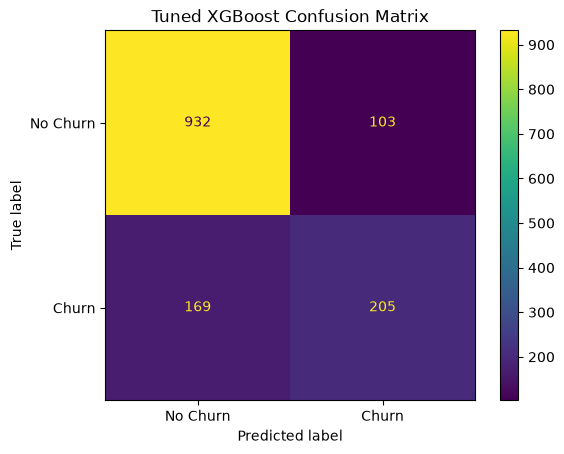

In [24]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb_tuned)
ConfusionMatrixDisplay(cm_xgb, display_labels=["No Churn", "Churn"]).plot()
plt.title("Tuned XGBoost Confusion Matrix")
plt.show()

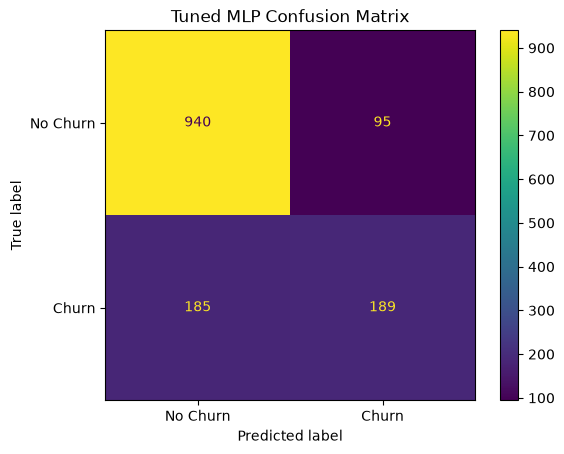

In [25]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp_tuned)
ConfusionMatrixDisplay(cm_mlp, display_labels=["No Churn", "Churn"]).plot()
plt.title("Tuned MLP Confusion Matrix")
plt.show()

## 7. Conclusion

Both XGBoost and Multilayer Perceptron (MLP) models were successfully developed and evaluated for customer churn prediction. Hyperparameter tuning improved the XGBoost model, increasing its F1-score from **0.5714** to **0.6012** and achieving the highest accuracy of **0.8070**. The baseline MLP achieved the highest overall F1-score of **0.6136** and the highest recall of **0.6497**, indicating better detection of customers who actually churned. However, the tuned MLP achieved a lower F1-score of **0.5745** on the test set. Overall, XGBoost provided the best accuracy and precision, while the baseline MLP provided better recall and F1-score for identifying churn customers.